In [ ]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l1, l2
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
#loading dataset
df = pd.read_excel('/content/Sonar_with_Column_Names.xlsx')
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V52,V53,V54,V55,V56,V57,V58,V59,V60,Class
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


In [ ]:
#performing basic EDA
print(df.shape)
print(df.info())
print(df.describe())

(208, 61)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 61 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      208 non-null    float64
 1   V2      208 non-null    float64
 2   V3      208 non-null    float64
 3   V4      208 non-null    float64
 4   V5      208 non-null    float64
 5   V6      208 non-null    float64
 6   V7      208 non-null    float64
 7   V8      208 non-null    float64
 8   V9      208 non-null    float64
 9   V10     208 non-null    float64
 10  V11     208 non-null    float64
 11  V12     208 non-null    float64
 12  V13     208 non-null    float64
 13  V14     208 non-null    float64
 14  V15     208 non-null    float64
 15  V16     208 non-null    float64
 16  V17     208 non-null    float64
 17  V18     208 non-null    float64
 18  V19     208 non-null    float64
 19  V20     208 non-null    float64
 20  V21     208 non-null    float64
 21  V22     208 non-null    float

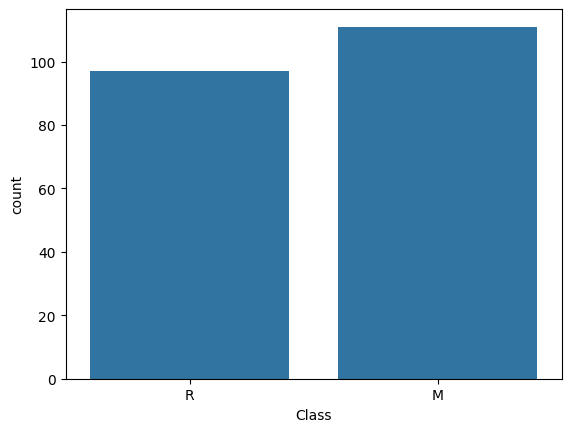

In [ ]:
sns.countplot(x=df['Class'])   # assuming target column is 'Class'
plt.show()

In [ ]:
print(df.isnull().sum())

V1       0
V2       0
V3       0
V4       0
V5       0
        ..
V57      0
V58      0
V59      0
V60      0
Class    0
Length: 61, dtype: int64


In [ ]:
le = LabelEncoder()
df['Class'] = le.fit_transform(df['Class'])

In [ ]:
X = df.drop('Class', axis=1)
y = df['Class']

In [ ]:
#splitting training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#Applying standard scaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
def build_model():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
model = build_model()

start_time = time.time()

history = model.fit(
    X_train, y_train,
    epochs=50,
    validation_split=0.2,
    verbose=1
)

end_time = time.time()
print("Training Time:", end_time - start_time)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.4924 - loss: 0.7252 - val_accuracy: 0.7059 - val_loss: 0.5665
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6515 - loss: 0.6168 - val_accuracy: 0.7353 - val_loss: 0.5309
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7803 - loss: 0.5495 - val_accuracy: 0.8824 - val_loss: 0.4998
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8182 - loss: 0.4978 - val_accuracy: 0.8824 - val_loss: 0.4706
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8485 - loss: 0.4569 - val_accuracy: 0.9412 - val_loss: 0.4479
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8561 - loss: 0.4218 - val_accuracy: 0.9118 - val_loss: 0.4288
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8636 - loss: 0.3952 - val_accuracy: 0.9118 - val_loss: 0.4119
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8939 - loss: 0.3693 - val_accuracy: 0.9412 - val_loss: 0.3985
Epoch 9/50


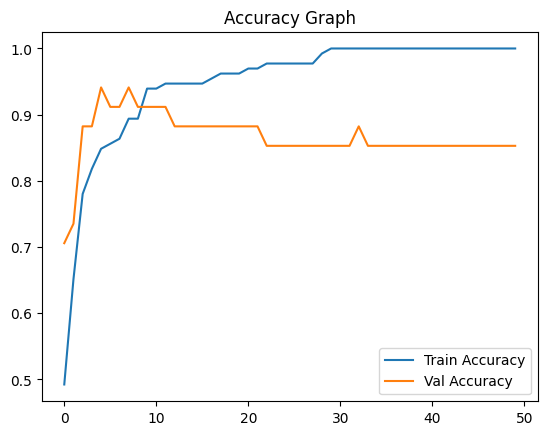

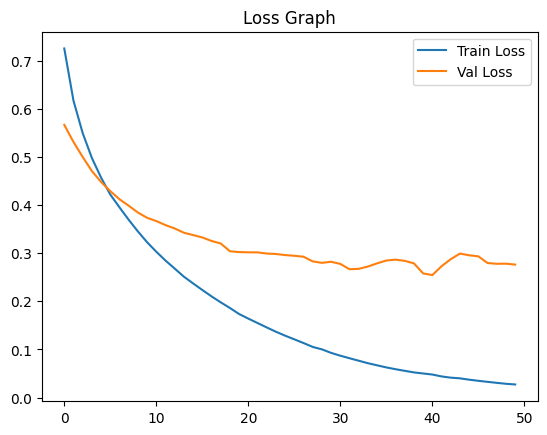

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss Graph")
plt.show()

In [ ]:
y_pred = (model.predict(X_test) > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Accuracy: 0.8571428571428571
[[22  4]
 [ 2 14]]
              precision    recall  f1-score   support

           0       0.92      0.85      0.88        26
           1       0.78      0.88      0.82        16

    accuracy                           0.86        42
   macro avg       0.85      0.86      0.85        42
weighted avg       0.86      0.86      0.86        42



In [ ]:
def model_l2():
    model = Sequential([
        Dense(64, activation='relu', kernel_regularizer=l2(0.01), input_shape=(X_train.shape[1],)),
        Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
def model_l1():
    model = Sequential([
        Dense(64, activation='relu', kernel_regularizer=l1(0.01), input_shape=(X_train.shape[1],)),
        Dense(32, activation='relu', kernel_regularizer=l1(0.01)),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
def model_dropout():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
def model_combined():
    model = Sequential([
        Dense(64, activation='relu', kernel_regularizer=l2(0.01), input_shape=(X_train.shape[1],)),
        Dropout(0.5),
        Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
models = {
    "Basic": build_model(),
    "L1": model_l1(),
    "L2": model_l2(),
    "Dropout": model_dropout(),
    "Combined": model_combined()
}

results = {}

for name, m in models.items():
    print(f"\nTraining {name} Model")

    history = m.fit(
        X_train, y_train,
        epochs=50,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0
    )

    y_pred = (m.predict(X_test) > 0.5).astype(int)
    acc = accuracy_score(y_test, y_pred)

    results[name] = acc

print("\nModel Comparison:")
for k, v in results.items():
    print(f"{k}: {v}")


Training Basic Model


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step

Training L1 Model
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step

Training L2 Model
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step

Training Dropout Model
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

Training Combined Model
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 540ms/step

Model Comparison:
Basic: 0.7619047619047619
L1: 0.6190476190476191
L2: 0.42857142857142855
Dropout: 0.6904761904761905
Combined: 0.5714285714285714


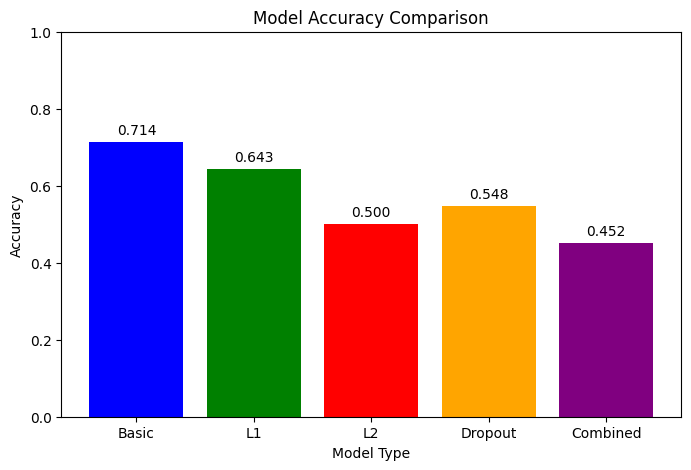

In [ ]:
import matplotlib.pyplot as plt

# Models and their scores
models = ['Basic', 'L1', 'L2', 'Dropout', 'Combined']
scores = [0.714, 0.643, 0.5, 0.548, 0.452]

# Create bar chart
plt.figure(figsize=(8,5))
plt.bar(models, scores, color=['blue', 'green', 'red', 'orange', 'purple'])
plt.ylim(0, 1)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model Type")

# Annotate bars with values
for i, score in enumerate(scores):
    plt.text(i, score + 0.02, f"{score:.3f}", ha='center')

plt.show()

In [ ]:
model.save("sonar_ann_model.keras")